### Scrap notebook for testing and plotting

In [1]:
from astropy.cosmology import Planck18
%env XLA_PYTHON_CLIENT_ALLOCATOR=platform
import astropy.units as u
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
from glob import glob
import lalsimulation as lalsim
import numpy as np
import os.path as op
import sys
import pandas as pd
sys.path.append('../src/')
import weighting
import jax.numpy as jnp
import h5py
import matplotlib.pyplot as plt
from tqdm import tqdm
import scipy
import mock_observations
import intensity_models
from scipy import special
#import re
#import os
from scipy.interpolate import RegularGridInterpolator
import jax
from importlib import reload 
#reload(fisher_snrs)
jax.local_devices()
jax.config.update("jax_enable_x64", True)
from inspect import getfullargspec


env: XLA_PYTHON_CLIENT_ALLOCATOR=platform


/mnt/home/amoran/GW_pop_cosmo_inference/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_true_vals(filename):
        tv = {}

        with open(filename) as f:
            for line in f:
                line = line.strip()

                if line and not line.startswith("#"):
                    key, val = line.split("=", 1)
                    tv[key.strip()] = float(val.strip())

        # transformed params expected by model
        tv['dkappa'] = tv['kappa'] - tv['lam']
        tv['log_fpl'] = np.log(tv['fpl'])
        tv['dmbhmax'] = tv['mbhmax'] - tv['mpisn']

        tv['log_flow'] = jnp.log(tv['flow'])
        tv['log_fpl'] = jnp.log(tv['fpl'])


        # remove unused raw params if desired
        del tv['kappa']
        del tv['fpl']
        del tv['mbhmax']

        return {k: jnp.array(v) for k, v in tv.items()}
    

In [3]:
population_parameters, cosmo_true = weighting.get_pop_params('pop_configs/mock_GWTC5_noevo.txt')


In [24]:
PE_files=[ '../runs/GWTC5_redone4_hr/PE_GWTC5_hr.h5',
          '../runs/mock_TC5_noevo_jul3/PE_noevo_hr.h5' ]
sel_files=[ '../runs/mock_TC5_noevo_jul3/sel_noevo.h5', 
           '../runs/mock_TC5_noevo_jul3/sel_noevo_nb.h5' ]

pe_samples_mock = pd.read_hdf(PE_files[0], key='samples')#.iloc[0:2000]# 1.5 to 2.5 k on the 1k tests
m1s_det = np.asarray(pe_samples_mock['m1'].to_list())
qs = np.asarray(pe_samples_mock['q'].to_list())#[:, :1000]
dls =  np.asarray(pe_samples_mock['dl'].to_list())
pdraws = np.asarray(pe_samples_mock['pdraw'].to_list())
#pdraws= jnp.nan_to_num(pdraws, neginf=-1e30, posinf=1e30)
zs=cosmo_true.z_of_dL(dls)
m1s_src= m1s_det / (1 + zs)
m2s_src= m1s_src*qs

sel_samples=pd.read_hdf(sel_files[1], key='true_parameters',  start=0, stop=371545)
ndraw=sel_samples['ndraw'].iloc[0]
m1s_sel= np.array(sel_samples['m1d'].to_list())
qs_sel=np.array(sel_samples['q'].to_list())
dls_sel=np.array(sel_samples['dl'].to_list())
pdraw_sel=np.array(sel_samples['pdraw_sel'].to_list())
zs_sel=cosmo_true.z_of_dL(dls_sel)
m1s_sel_src= m1s_sel / (1 + zs_sel)
m2s_sel_src= m1s_sel_src*qs_sel


133469


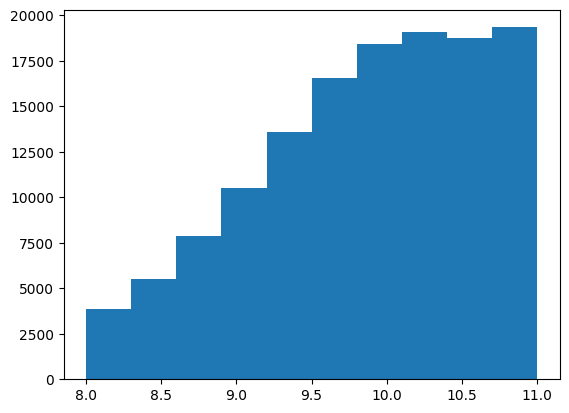

In [21]:
mass_gap_samps = m1s_src.ravel()[(m1s_src.ravel() > 8) & (m1s_src.ravel() < 11)]
plt.hist(mass_gap_samps)
print(len(mass_gap_samps))

In [28]:
with h5py.File(PE_files[1], "r") as f:
    m1s_det = f["m1"][1000:2000]
    qs = f["q"][1000:2000]
    dls = f["dl"][1000:2000]
    pdraws = f["pdraw"][1000:2000]


zs=cosmo_true.z_of_dL(dls)
m1s_src= m1s_det / (1 + zs)
m2s_src= m1s_src*qs

1629289


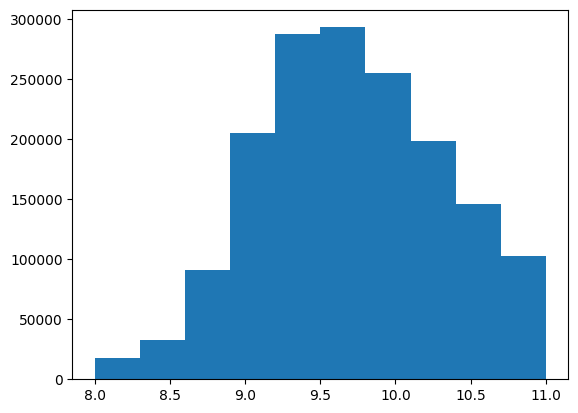

In [29]:
mass_gap_samps = m1s_src.ravel()[(m1s_src.ravel() > 8) & (m1s_src.ravel() < 11)]
plt.hist(mass_gap_samps)
print(len(mass_gap_samps))

In [5]:
import gc
gc.collect()
import jax.scipy.special as jss


In [77]:
import jax.numpy as jnp
import jax.scipy.special as jss
import numpy as np
import matplotlib.pyplot as plt

import intensity_models  # your module

truth = dict(
    a=-0.336, b=-1.60, c=2.57,
    mpisn=34.11, mpisndot=0.0, mbhmax=37.22, sigma=0.054,
    fpl=0.65573, beta=-2.71,
    lam=4.72, kappa=9.25, zp=0.781,
    flow=0.40,
    mco_min=8.0, mbh_min=3.0, delta_m=1.6, zmax=6.5,
)

log_pdraw = jnp.asarray(pdraws)
log_pdraw_sel = jnp.log(jnp.asarray(pdraw_sel))
nsamp = m1s_src.shape[1]

m1s_src_j, qs_j, zs_j = map(jnp.asarray, (m1s_src, qs, zs))
m1s_sel_src_j, qs_sel_j, zs_sel_j = map(jnp.asarray, (m1s_sel_src, qs_sel, zs_sel))


def diagnostics(mp_low, msigma_low, nobs=None):
    """Like total_loglike, but also returns per-event neff array and neff_sel.

    Returns
    -------
    total : float
        total log-likelihood (event term - n*log_mu_sel)
    neff_per_event : np.ndarray, shape (nobs,)
        per-event effective sample size from the MC sum over PE samples
    neff_sel : float
        effective sample size of the selection-function MC sum over injections
    log_like_per_event : np.ndarray, shape (nobs,)
    """
    params = dict(truth)
    params['mp_low'] = mp_low
    params['msigma_low'] = msigma_low

    log_dN = intensity_models.LogDNDMDQDV(**params)

    # --- event term ---
    log_dN_vals = log_dN(m1s_src_j, qs_j, zs_j)
    log_wts = (log_dN_vals - log_pdraw
               - 2*jnp.log1p(zs_j)
               - jnp.log(cosmo_true.ddL_dz(zs_j))
               + jnp.log(cosmo_true.dVCdz(zs_j)))

    log_like_per_event = jss.logsumexp(log_wts, axis=1) - jnp.log(nsamp)
    log_like_per_event = jnp.nan_to_num(log_like_per_event, nan=0, posinf=1e30, neginf=-1e30)

    # per-event effective sample size (over the PE-sample MC sum)
    neff_per_event = jnp.exp(
        2*jss.logsumexp(log_wts, axis=1) - jss.logsumexp(2*log_wts, axis=1)
    )

    n = nobs if nobs is not None else log_like_per_event.shape[0]
    log_like = jnp.sum(log_like_per_event[:n])

    # --- selection term ---
    log_dN_sel_vals = log_dN(m1s_sel_src_j, qs_sel_j, zs_sel_j)
    log_sel_wts = (log_dN_sel_vals - log_pdraw_sel
                   - 2*jnp.log1p(zs_sel_j)
                   + jnp.log(cosmo_true.dVCdz(zs_sel_j))
                   - jnp.log(cosmo_true.ddL_dz(zs_sel_j)))
    log_mu_sel = jss.logsumexp(log_sel_wts) - jnp.log(ndraw)

    # effective sample size of the selection-function estimator
    # (mirrors the neff_sel formula used in pop_cosmo_model)
    log_mu2 = jss.logsumexp(2*log_sel_wts) - 2*jnp.log(ndraw)
    log_s2 = log_mu2 + jnp.log1p(-jnp.exp(2*log_mu_sel - jnp.log(ndraw) - log_mu2))
    neff_sel = jnp.exp(2*log_mu_sel - log_s2)

    total = log_like - n*log_mu_sel

    return (float(total),
            np.asarray(neff_per_event[:n]),
            float(neff_sel),
            np.asarray(log_like_per_event[:n]))


In [86]:
# ----------------------------------------------------------------------
# Grid scan, mirroring your existing sig_vals sweep, but now recording
# per-event neff arrays at each grid point for a few mp_low values.
# ----------------------------------------------------------------------
sig_vals = [ .005, .01, .02, .035, .05, 0.1, 0.15, 0.2, 0.3, 0.4285, 0.6, 1]
mp_vals_to_check = {"truth (9.4)": 9.4, "spurious (9.6)": 9.6, "spurious (9.8)": 9.8}

results = {}  # label -> dict(loglike=[], min_neff=[], med_neff=[], neff_sel=[], neff_matrix=[])

for label, mp in mp_vals_to_check.items():
    loglikes, min_neffs, med_neffs, neff_sels, neff_matrix = [], [], [], [], []
    for s in sig_vals:
        total, neff_pe, neff_sel, _ = diagnostics(mp_low=mp, msigma_low=s)
        loglikes.append(total)
        min_neffs.append(np.min(neff_pe))
        med_neffs.append(np.median(neff_pe))
        neff_sels.append(neff_sel)
        neff_matrix.append(neff_pe)
        print(f"[{label:16s}] sigma={s:7.4f}  loglike={total:14.3f}  "
              f"min_neff={np.min(neff_pe):9.3f}  med_neff={np.median(neff_pe):9.3f}  "
              f"neff_sel={neff_sel:10.3f}")
    results[label] = dict(
        loglike=np.array(loglikes),
        min_neff=np.array(min_neffs),
        med_neff=np.array(med_neffs),
        neff_sel=np.array(neff_sels),
        neff_matrix=np.array(neff_matrix),  # shape (n_sigma, nobs)
    )


[truth (9.4)     ] sigma= 0.0050  loglike=    -12341.669  min_neff=    1.027  med_neff=   26.015  neff_sel=  1947.615
[truth (9.4)     ] sigma= 0.0100  loglike=    -12202.474  min_neff=    1.069  med_neff=   43.259  neff_sel=  6662.886
[truth (9.4)     ] sigma= 0.0200  loglike=    -12107.164  min_neff=    1.183  med_neff=   72.634  neff_sel= 29697.441
[truth (9.4)     ] sigma= 0.0350  loglike=    -12238.491  min_neff=    1.354  med_neff=  115.685  neff_sel= 44584.795
[truth (9.4)     ] sigma= 0.0500  loglike=    -12313.809  min_neff=    1.893  med_neff=  156.482  neff_sel= 45727.265
[truth (9.4)     ] sigma= 0.1000  loglike=    -12297.719  min_neff=    6.970  med_neff=  288.843  neff_sel=100144.749
[truth (9.4)     ] sigma= 0.1500  loglike=    -12268.273  min_neff=   17.470  med_neff=  429.260  neff_sel=175556.781
[truth (9.4)     ] sigma= 0.2000  loglike=    -12252.105  min_neff=   32.317  med_neff=  568.863  neff_sel=244310.249
[truth (9.4)     ] sigma= 0.3000  loglike=    -12235.948

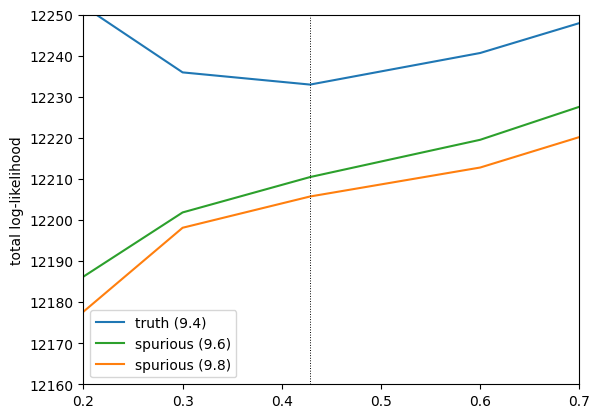

In [99]:
for label in mp_vals_to_check:

    plt.plot(sig_vals, np.abs(results[label]["loglike"]), color=colors[label], label=label)
plt.axvline(0.4285, color="k", linewidth=0.7, linestyle=":")
plt.ylabel("total log-likelihood")
plt.xlim(.2, .7)
plt.ylim(12160, 12250)
plt.legend()


Saved plot to neff_diagnostic.png


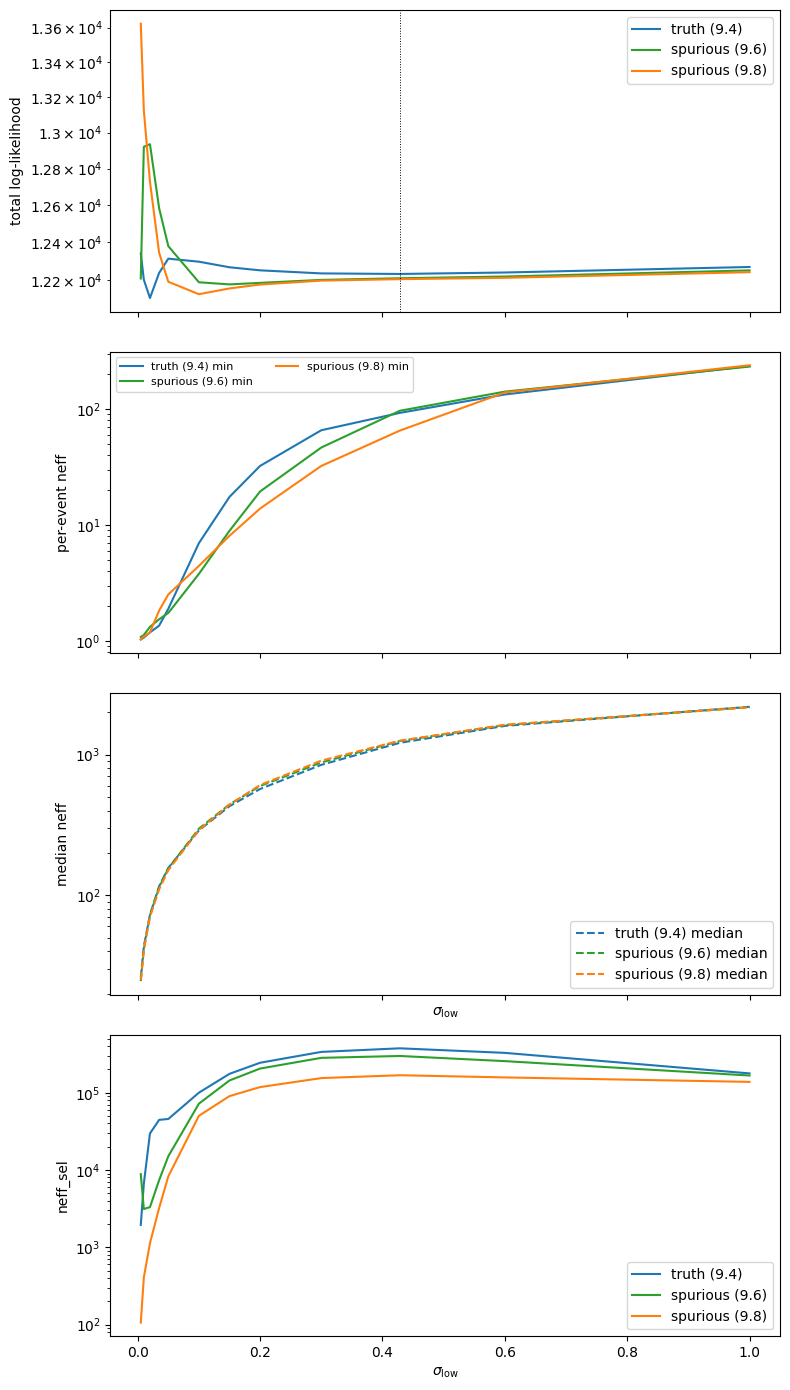

In [92]:
colors = {"truth (9.4)": "tab:blue", "spurious (9.6)": "tab:green", "spurious (9.8)": "tab:orange"}

fig, axes = plt.subplots(4, 1, figsize=(8, 14), sharex=True)

ax = axes[0]
for label in mp_vals_to_check:
    ax.plot(sig_vals, np.abs(results[label]["loglike"]), color=colors[label], label=label)
ax.axvline(0.4285, color="k", linewidth=0.7, linestyle=":")
ax.set_ylabel("total log-likelihood")
ax.set_yscale("log")
ax.legend()

ax = axes[1]
for label in mp_vals_to_check:
    ax.plot(sig_vals, results[label]["min_neff"], color=colors[label], linestyle="-", label=f"{label} min")
ax.set_ylabel("per-event neff")
ax.set_yscale("log")
ax.legend(fontsize=8, ncol=2)

ax = axes[2]
for label in mp_vals_to_check:
    ax.plot(sig_vals, results[label]["med_neff"], color=colors[label], linestyle="--", label=f"{label} median")
ax.set_ylabel("median neff")
ax.set_xlabel(r"$\sigma_{\rm low}$")
ax.set_yscale("log")
ax.legend()

ax = axes[3]
for label in mp_vals_to_check:
    ax.plot(sig_vals, results[label]["neff_sel"], color=colors[label], label=label)
ax.set_ylabel("neff_sel")
ax.set_xlabel(r"$\sigma_{\rm low}$")
ax.set_yscale("log")
ax.legend()

fig.tight_layout()
fig.savefig("neff_diagnostic.png", dpi=150)
print("\nSaved plot to neff_diagnostic.png")


In [ ]:
spike_label = "spurious (9.8)"
spike_sigma_idx = sig_vals.index(0.05)  # adjust to wherever your spike peaks
neff_at_spike = results[spike_label]["neff_matrix"][spike_sigma_idx]
worst_event_idx = np.argsort(neff_at_spike)[:10]
print(f"\nEvents with lowest neff at {spike_label}, sigma={sig_vals[spike_sigma_idx]}:")
for i in worst_event_idx:
    print(f"  event {i}: neff={neff_at_spike[i]:.3f}, "
          f"m1_src range=[{np.min(np.asarray(m1s_src_j[i])):.2f}, {np.max(np.asarray(m1s_src_j[i])):.2f}], "
          f"nearest sample to mp={mp_vals_to_check[spike_label]}: "
          f"{np.asarray(m1s_src_j[i])[np.argmin(np.abs(np.asarray(m1s_src_j[i]) - mp_vals_to_check[spike_label]))]:.3f}")


Events with lowest neff at spurious (9.8), sigma=0.05:
  event 138: neff=2.516, m1_src range=[8.22, 551.38], nearest sample to mp=9.8: 9.805
  event 5: neff=3.276, m1_src range=[8.75, 22.17], nearest sample to mp=9.8: 9.816
  event 227: neff=3.734, m1_src range=[2.82, 23.25], nearest sample to mp=9.8: 9.799
  event 78: neff=4.127, m1_src range=[4.26, 40.51], nearest sample to mp=9.8: 9.799
  event 168: neff=4.644, m1_src range=[2.04, 69.04], nearest sample to mp=9.8: 9.799
  event 242: neff=4.763, m1_src range=[3.26, 49.39], nearest sample to mp=9.8: 9.801
  event 36: neff=5.101, m1_src range=[8.39, 245.85], nearest sample to mp=9.8: 9.800
  event 305: neff=5.102, m1_src range=[8.02, 20.62], nearest sample to mp=9.8: 9.788
  event 228: neff=5.503, m1_src range=[4.00, 129.03], nearest sample to mp=9.8: 9.804
  event 771: neff=5.607, m1_src range=[8.45, 22.29], nearest sample to mp=9.8: 9.802


In [85]:
spike_label = "truth (9.4)"
spike_sigma_idx = sig_vals.index(0.05)  # adjust to wherever your spike peaks
neff_at_spike = results[spike_label]["neff_matrix"][spike_sigma_idx]
worst_event_idx = np.argsort(neff_at_spike)[:10]
print(f"\nEvents with lowest neff at {spike_label}, sigma={sig_vals[spike_sigma_idx]}:")
for i in worst_event_idx:
    print(f"  event {i}: neff={neff_at_spike[i]:.3f}, "
          f"m1_src range=[{np.min(np.asarray(m1s_src_j[i])):.2f}, {np.max(np.asarray(m1s_src_j[i])):.2f}], "
          f"nearest sample to mp={mp_vals_to_check[spike_label]}: "
          f"{np.asarray(m1s_src_j[i])[np.argmin(np.abs(np.asarray(m1s_src_j[i]) - mp_vals_to_check[spike_label]))]:.3f}")


Events with lowest neff at truth (9.4), sigma=0.05:
  event 227: neff=1.893, m1_src range=[2.82, 23.25], nearest sample to mp=9.4: 9.402
  event 5: neff=2.731, m1_src range=[8.75, 22.17], nearest sample to mp=9.4: 9.411
  event 747: neff=3.050, m1_src range=[7.25, 37.19], nearest sample to mp=9.4: 9.397
  event 830: neff=3.071, m1_src range=[9.27, 12.96], nearest sample to mp=9.4: 9.424
  event 78: neff=3.213, m1_src range=[4.26, 40.51], nearest sample to mp=9.4: 9.383
  event 140: neff=3.242, m1_src range=[6.38, 111.84], nearest sample to mp=9.4: 9.402
  event 825: neff=3.488, m1_src range=[9.31, 17.91], nearest sample to mp=9.4: 9.406
  event 876: neff=4.336, m1_src range=[9.47, 12.96], nearest sample to mp=9.4: 9.468
  event 228: neff=4.743, m1_src range=[4.00, 129.03], nearest sample to mp=9.4: 9.394
  event 875: neff=4.796, m1_src range=[9.26, 13.30], nearest sample to mp=9.4: 9.441


In [3]:
truth_params=load_true_vals('../scripts/pop_configs/mock_GWTC5_noevo.txt')
extra_params=intensity_models.get_deterministic_parameters(truth_params)
truth_params.update(extra_params)

In [5]:
population_parameters, cosmo_true = weighting.get_pop_params('pop_configs/mock_GWTC5_noevo.txt')
log_dN_obj = intensity_models.LogDNDMDQDV
pop_params = {key: population_parameters[key] for key in getfullargspec(log_dN_obj)[0][1:] if key in population_parameters.keys()}
log_dN_func = log_dN_obj(**pop_params)
log_dN_func(6, .5, 4)

Array(-97.06717349, dtype=float64)

In [90]:
def full_loglik_proxy(
    h_val,
    true_params,
    m1s_det, qs, dls, log_pdraw,
    dls_sel, m1s_det_sel, qs_sel, pdraw_sel, Ndraw, keep_mask,
    Om=0.315, w=-1, zmax=6.5
):

    sample = {**true_params, 'h': h_val}

    cosmo = intensity_models.FlatwCDMCosmology(
        sample['h'], Om, w, zmax=zmax
    )
    log_dN = intensity_models.build_population_model(sample)

    # ---------------- event term ----------------

    zs = cosmo.z_of_dL(dls)
    m1s = m1s_det / (1.0 + zs)

    log_wts = (
        log_dN(m1s, qs, zs)
        - log_pdraw
        - 2.0 * jnp.log1p(zs)
        - jnp.log(cosmo.ddL_dz(zs))
        + jnp.log(cosmo.dVCdz(zs))
    )

    # ignore samples with true source-frame m2 < 4
    log_wts = jnp.where(keep_mask, log_wts, -jnp.inf)

    n_keep = jnp.sum(keep_mask, axis=1)
    n_keep = jnp.maximum(n_keep, 1)

    event_ll = jnp.sum(
        jss.logsumexp(log_wts, axis=1)
        - jnp.log(n_keep)
    )

    # ---------------- selection term ----------------
    zs_sel = cosmo.z_of_dL(dls_sel)
    m1s_sel = m1s_det_sel / (1 + zs_sel)

    log_sel_wts = (
        log_dN(m1s_sel, qs_sel, zs_sel)
        - jnp.log(pdraw_sel)
        - 2 * jnp.log1p(zs_sel)
        + jnp.log(cosmo.dVCdz(zs_sel))
        - jnp.log(cosmo.ddL_dz(zs_sel))
    )

    log_mu_sel = jss.logsumexp(log_sel_wts) - jnp.log(Ndraw)

    selection_ll = -m1s_det.shape[0] * log_mu_sel

    return event_ll + selection_ll

In [93]:
def load_true_vals(filename):
    tv = {}

    with open(filename) as f:
        for line in f:
            line = line.strip()

            if line and not line.startswith("#"):
                key, val = line.split("=", 1)
                tv[key.strip()] = float(val.strip())

    # transformed params expected by model
    tv['dkappa'] = tv['kappa'] - tv['lam']
    tv['log_fpl'] = np.log(tv['fpl'])
    tv['dmbhmax'] = tv['mbhmax'] - tv['mpisn']

    # remove unused raw params if desired
    del tv['kappa']
    del tv['fpl']
    del tv['mbhmax']

    return {k: jnp.array(v) for k, v in tv.items()}
#truth_file_name='pop_configs/mock_GWTC5_evo_mmin4_nerr.txt'
#if truth_file_name is not None:
#    print("Loading truth parameters from: ", truth_file_name)
#    truth_params=load_true_vals(truth_file_name)

In [94]:
h_grid = jnp.linspace(0.4, 1.0, 10)
zs=cosmo_true.z_of_dL(dls)
m1s_src= m1s_det / (1 + zs)
m2s_src= m1s_src*qs
mask=np.where(m2s_src>0)[0]

In [95]:
sample = {**true_params, 'h': .674}
cosmo_fid = intensity_models.FlatwCDMCosmology(
        sample['h'],  Om=0.315, w=-1, zmax=6.5)

In [75]:
zs_true = cosmo_fid.z_of_dL(dls)
m1s_src_true = m1s_det / (1.0 + zs_true)
m2s_src_true = m1s_src_true * qs

keep_mask = m2s_src_true > 0
true_params['mbh_min']=3
true_params['delta_m']=1.6

In [96]:
import jax.scipy.special as jss

In [77]:
gc.collect()

44

In [78]:
full_vals_seldm1 = jnp.array([
    full_loglik_proxy(
        float(h),
        true_params,
        m1s_det, qs, dls, pdraws,
        dls_sel, m1s_sel, qs_sel, pdraw_sel, ndraw, keep_mask
    )
    for h in h_grid
])

In [102]:
sample = {**true_params, 'h': .674}
cosmo_fid = intensity_models.FlatwCDMCosmology(
        sample['h'],  Om=0.315, w=-1, zmax=6.5)

zs_true = cosmo_fid.z_of_dL(dls)
m1s_src_true = m1s_det / (1.0 + zs_true)
m2s_src_true = m1s_src_true * qs

keep_mask = m2s_src_true > 0
true_params['mbh_min']=3
true_params['delta_m']=1.6

full_vals_seldm2 = jnp.array([
    full_loglik_proxy(
        float(h),
        true_params,
        m1s_det, qs, dls, pdraws,
        dls_sel, m1s_sel, qs_sel, pdraw_sel, ndraw, keep_mask
    )
    for h in h_grid
])

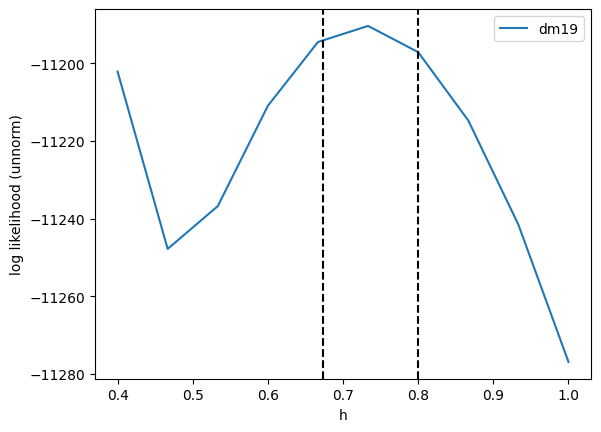

In [105]:
#plt.plot(h_grid, (full_vals_seldm1), label="it 1")
plt.plot(h_grid, (full_vals_seldm2), label="dm19")

plt.axvline(0.674, ls="--", color="k")
plt.axvline(0.8, ls="--", color="k")

plt.legend()
plt.xlabel("h")
plt.ylabel("log likelihood (unnorm)")
plt.show()

In [ ]:
grid_file='snr_grid_aplus.npz'
grid=np.load(grid_file)
m1_grid  = grid["m1_grid"]
q_grid   = grid["q_grid"]
snr_grid = grid["snr_grid"]
dL_fid   = float(grid["dL_fid"])
log_snr_interp = RegularGridInterpolator((m1_grid, q_grid), np.log(snr_grid), bounds_error=False, fill_value=-np.inf)



/tmp/ipykernel_2637405/2473520272.py:7: RuntimeWarning: divide by zero encountered in log
  log_snr_interp = RegularGridInterpolator((m1_grid, q_grid), np.log(snr_grid), bounds_error=False, fill_value=-np.inf)


### Errors

In [14]:
def get_X_logmc(M, SNR, sigma_M):
    """
    Take chirp mass, SNR, and upper and lower bounds on chirp mass.
    Propogate those bounds to log chirp mass bounds
    solve for the linear factor we would use to go from SNR to sigma_log_mc

    Also works for log chirp mass!
    """
    sigma_M=jnp.array(sigma_M)
    log_mc=jnp.log(M)
    sigma_log_mc=np.mean(sigma_M/M) #propogate error and collapse to symmetric errors 
    return SNR*sigma_log_mc  #sigma_log_mc= X/SNR

def get_X_q(SNR, sigma_q):
    """
    solve for the linear factor we would use to go from SNR to sigma_q
    This is old, we now use log_q error
    """
    sigma_q=np.mean(sigma_q) #collapse to symmetric
    return SNR*sigma_q #sigma_q= X/SNR


In [99]:
# Event data: (SNR, M, [lower_error, upper_error])
# all 35 events here: https://gwosc.org/eventapi/html/GWTC-3-confident/
events = [(4.5, 15.0, [29.5, 4.0]),
    (10.3, 8.75, [0.62, 0.55]),
    (17.8, 6.6, [2.4, 2.0]),
    (4.7, 34, [44, 18]),
    (7.8, 17.5, [3.5, 3.0]),
    (10.8, 23.4, [4.7, 3.0]),
    (12.5, 14.2, [1.5, 1.4]),
    (20.0, 31.1, [3.3, 2.7]),
    (8.5, 28.2, [7.3, 5.1]),
    (7.2, 62, [23, 15]),
    (10.7, 27.6, [5.6, 3.8]),
    (8.1, 32.9, [9.3, 8.5]),
    (8.4, 6.56, [0.38, 0.40]),
    (9.6, 26.7, [6.0, 4.2]),
    (7.4, 19.8, [10.5, 5.2]),
    (10.8, 27.7, [3.7, 3.1]),
    (10.8, 7.49, [0.24, 0.2]),
    (26.8, 27.2, [2.1, 2.3]),
    (10.6, 32.0, [7.5, 5.5]),
    (11.3, 2.43, [0.05, 0.07]),
    (19.8, 27.4, [2.6, 2.1]),
    (10.4, 36.5, [8.2, 5.6]),
    (12.5, 33.8, [7.1, 5.0]),
    (9.1, 4.31, [0.12, 0.17]),
    (18.6, 8.33, [0.22, 0.19]),
    (11.2, 18.4, [2.2, 1.7]),
    (17.4, 8.56, [0.41, 0.28]),
    (8.9, 19.8, [3.6, 3.2]),
    (13.1, 7.31, [0.43, 0.28]),
    (9.2, 29.9, [11.7, 9.1]),
    (8.3, 8.65, [0.95, 0.71]),
    (7.9, 10.7, [1.1, 1.0]),
    (17.3, 47.5, [9.6, 7.5]),
    (9.7, 7.82, [0.61, 0.45]),
    (8.9, 8.34, [0.66, 0.57])]

Xs_1 = [get_X_logmc(M, SNR, errors) for SNR, M, errors in events]

print("Mean X:", np.mean(Xs_1))
print("Std X:", np.std(Xs_1))

Mean X: 1.767974784089777
Std X: 1.3006138540035586


In [100]:
events_q= [(4.5, 0.3, [0.7, 0.7]),
(10.3, 0.6, [0.4, 0.4]),
(17.8, 0.8, [0.2, 0.2]),
(4.7, 0.4, [0.8, 0.8]),
(7.8, 0.5, [0.3, 0.3]),
(10.8, 0.5, [0.2, 0.2]),
(12.5, 0.7, [0.2, 0.2]),
(20.0, 0.8, [0.2, 0.2]),
(8.5, 0.7, [0.3, 0.3]),
(7.2, 0.7, [0.4, 0.4]),
(10.7, 0.7, [0.3, 0.3]),
(8.1, 0.6, [0.4, 0.4]),
(8.4, 0.117427385892116, [0.0347841574263123, 0.0347841574263123]),
(9.6, 0.8, [0.3, 0.3]),
(7.4, 0.2, [0.3, 0.3]),
(10.8, 0.7, [0.2, 0.2]),
(10.8, 0.7, [0.2, 0.2]),
(26.8, 0.8, [0.2, 0.2]),
(10.6, 0.8, [0.3, 0.3]),
(11.3, 0.244067796610169, [0.133543137064012, 0.133543137064012]),
(19.8, 0.8, [0.2, 0.2]),
(10.4, 0.7, [0.3, 0.3]),
(12.5, 0.8, [0.3, 0.3]),
(9.1, 0.037620578778135, [0.00367611097618323, 0.00367611097618323]),
(18.6, 0.6, [0.2, 0.2]),
(11.2, 0.7, [0.2, 0.2]),
(17.4, 0.7, [0.2, 0.2]),
(8.9, 0.7, [0.3, 0.3]),
(13.1, 0.6, [0.2, 0.2]),
(9.2, 0.5, [0.4, 0.4]),
(8.3, 0.7, [0.3, 0.3]),
(7.9, 0.2, [0.1, 0.1]),
(17.3, 0.7, [0.2, 0.2]),
(9.7, 0.7, [0.2, 0.2]),
(8.9, 0.7, [0.3, 0.3])]



Xs_q = [get_X_q(SNR, errors) for SNR, _, errors in events_q]
SNRS=[]
for i in range(len(events_q)):
    SNRS.append(events_q[i][0])
print("Mean X:", np.mean(Xs_q)) 
print("Std X:", np.std(Xs_q))

Mean X: 2.7958479137453605
Std X: 1.0628760418098722


### LIGO way

In [ ]:
import sys
sys.path.append('../src/')
import weighting
import h5py
from astropy.cosmology import Planck18
import jax.scipy.special as jss
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal
import pandas as pd
import numpy as np

/mnt/home/amoran/GW_pop_cosmo_inference/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
reload(weighting)

NameError: name 'reload' is not defined

In [68]:
#('/home/reed.essick/rates+pop/o3-sensitivity-estimates/LIGO-T2100113-v11/endo3_bbhpop-LIGO-T2100113-v11.hdf5', nsamp=None, desired_pop_wt=None)
m1, q, z, a1, a2, cos_tilt1, cos_tilt2, pdraw, ndraw = weighting.sel_samples_mock('../endo3_bbhpop-LIGO-T2100113-v12.hdf5', 
                                                                                  detectors=detectors, SNR=8, 
                                                                                  sensitivity='o3_PSD',  SNR_load=True,
                                                                                  SNR_write=False,  SNR_file='LIGO_SNR_1222.txt')
df = pd.DataFrame({'m1': m1, 'q': q, 'z': z, 'a1': a1, 'a2':a2, 'cos_tilt_1': cos_tilt1, 'cos_tilt_2': cos_tilt2, 'pdraw_m1sqz': pdraw, 'ndraw': ndraw}) 

In [70]:
df['dm1sz_dm1ddl'] = 1/ ((1+df['z'].values))*cosmo.ddL_dz(df['z'].values)
# weighting.dm1sz_dm1ddl(df['z'])#gives us factor to go soruce to detector frame mass, and z to dL in prior
df.to_hdf('./selection_samples_o3_1230.h5', 'samples')

/tmp/ipykernel_1659843/2770026045.py:3: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  df.to_hdf('./selection_samples_o3_1230.h5', 'samples')
